In [10]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time
import lib

In [11]:
rootfolder = '.'

Load the image and rescale it in $[0,1]$

In [12]:
img = imread(f'{rootfolder}/data/cameraman.png') / 255
img = img[50:200, 50:200]
imsz = img.shape

# patch size
p = 7

# number of elements in the patch
M = p ** 2

# radius of the search neighborhood
H = 12


Corrupt the image with white gaussian noise

In [13]:
sigma_noise = 20/255
noisy_img = img + sigma_noise * np.random.randn(*img.shape)

Compute the psnr of the noisy input

In [14]:
psnr_noisy = lib.get_psnr(img, noisy_img)

Text(0.5, 1.0, 'Noisy image, PSNR = 22.12')

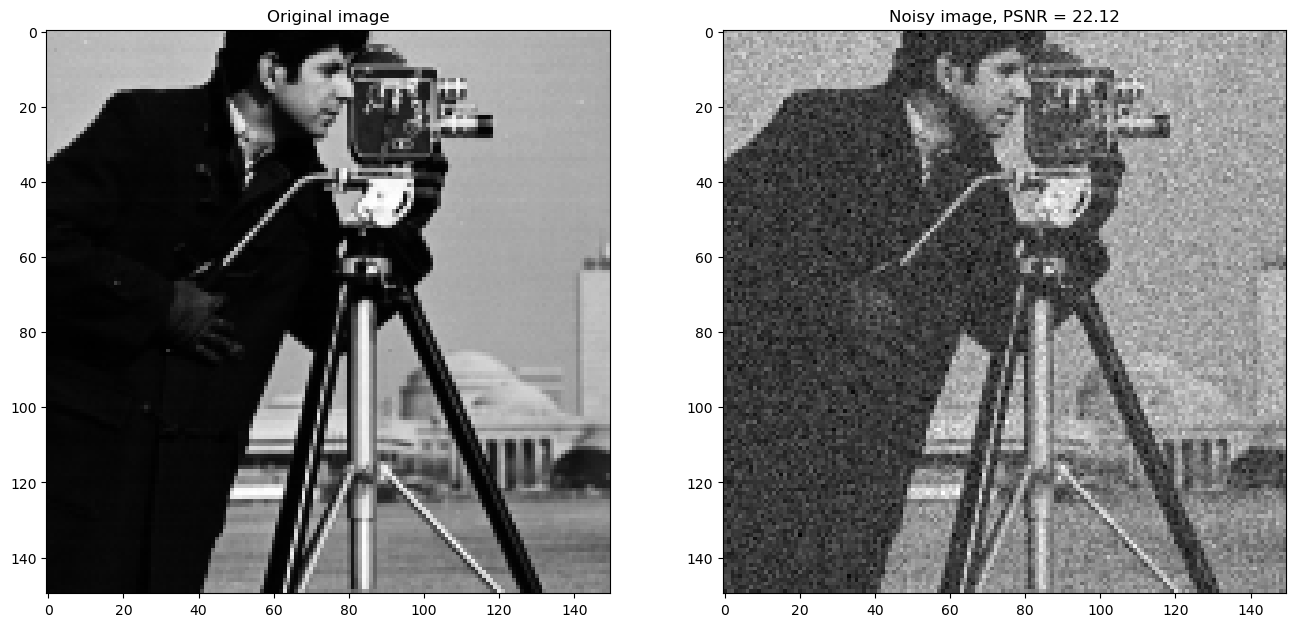

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Pixel-based NL-Means
--------------------
Set parameters and initialize the variables

In [16]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# pad the noisy image
img_pad = np.pad(noisy_img, p // 2, mode='symmetric')


Main loop

In [17]:
# loop through each pixel in the noisy image
for i in range(imsz[0]):
    for j in range(imsz[1]):
        # extract the reference patch centered at (i, j)
        s = img_pad[i:i+p, j:j+p]
        
        # initialize the pixel estimate and total weight
        pixel_hat, weight = 0, 0
        
        # define the search window bounds using the radius H
        r_min, r_max = max(0, i - H), min(imsz[0] - p // 2, i + H)
        c_min, c_max = max(0, j - H), min(imsz[1] - p // 2, j + H)
        
        for r in range(r_min, r_max):
            for c in range(c_min, c_max):
                # extract the neighboring patch
                z = img_pad[r:r+p, c:c+p]
                
                # compute the distance and weight
                d = np.linalg.norm(s - z)
                w = np.exp(-d / (M * sigma_noise ** 2))
                
                # update the pixel estimate
                pixel_hat += w * img_pad[r + p // 2, c + p // 2]

                # update the total weight
                weight += w

        # compute the weighted average
        img_hat[i, j] = pixel_hat / weight


Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 26.81')

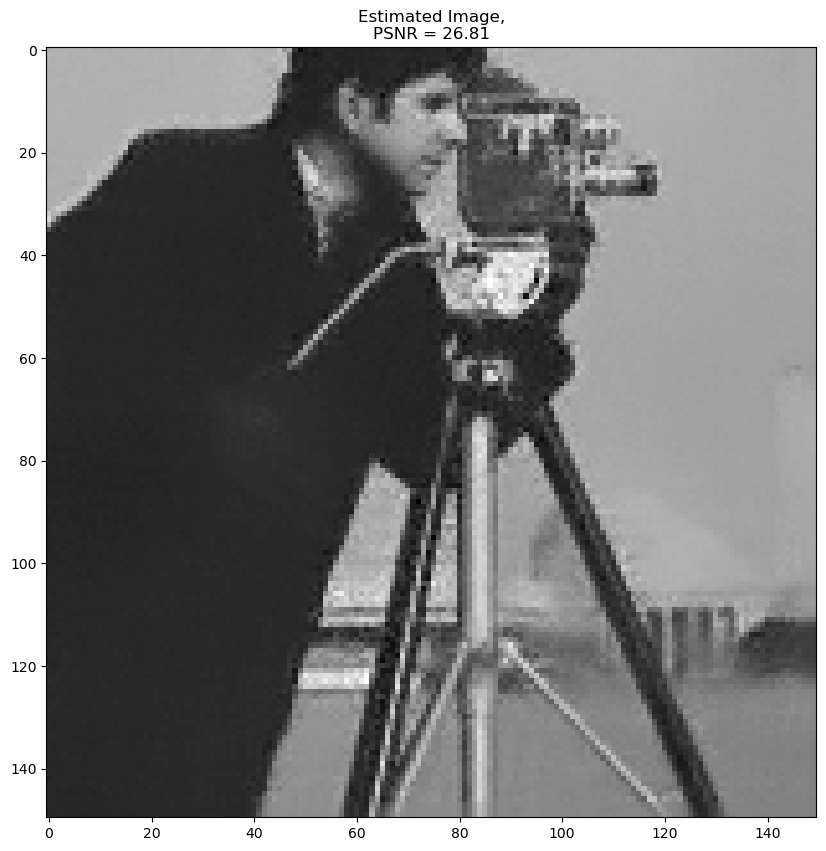

In [18]:
psnr_hat = lib.get_psnr(img, img_hat)
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')
